# Loan Defaulter Analysis

**Probability of default (PD)** on the Kaggle Home Credit application table.

The goal is not high accuracy. A model that always predicts “will pay” is ~92% accurate and useless. Two lending errors compete:

- **False negative** — approve a future defaulter → credit loss
- **False positive** — reject a future repayer → lost interest and volume

`TARGET = 1` means payment difficulty. That is the rare, expensive class (~8% of applications).


In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import itertools

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    roc_curve,
)
from sklearn.utils import resample

from yellowbrick.features import Rank2D
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

RANDOM_STATE = 10


# Load data into dataframe

In [2]:
# Data loading into dataframe
df = pd.read_csv('application_data.csv')

# Check the dimension of the table

In [3]:
# .shape gives us rows and columns in the form of tuple which we can seperate it by indexing
print('The dimension of the table is: ', df.shape)
print(f'This dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

The dimension of the table is:  (307511, 122)
This dataset has 307511 rows and 122 columns.


# Look at the data

In [4]:
# Displaying top 5 rows of data
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Questions that might help us predict who will be a loan defaulter:

1. Does default rate move with **age**, **education**, **income**, and **contract type**?
2. Which amount and household fields are **collinear** (credit vs goods price, region ratings, children vs family size)?
3. Can raw income and credit **separate** payers from defaulters, or do the classes overlap?
4. After that EDA, can a leakage-safe model rank risk using **external scores, payment burden, and employment** — not accuracy?

Gender is examined as a rate gap, then **left out of the model** (protected class).


## Before answering any questions we need to eliminate columns that are not required for the project

### Checking columns name

In [5]:
df.columns.values

array(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
       'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3',

In [6]:
# Checking each column null values out of 100
100*df.isnull().sum()/len(df)

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64

In [7]:
# Droping columns from our dataframe if columns has more than 50 percent of missing values
df.drop(df.columns[(100*df.isnull().sum()/len(df))>=50], axis=1, inplace= True)
# Checking for columns again
df.columns.values

array(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'YEARS_BEGINEXPLUATATION_AVG',

In [ ]:
# Drop IDs, housing aggregates, document flags, and bureau-query counts.
# Keep EXT_SOURCE_2 and EXT_SOURCE_3: they are normalized external credit
# scores and the strongest application-time predictors in this dataset.
# EXT_SOURCE_1 was already removed above (>50% missing).
df = df.drop([
    'SK_ID_CURR',
    'YEARS_BEGINEXPLUATATION_AVG', 'FLOORSMAX_AVG',
    'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE',
    'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
    'YEARS_BEGINEXPLUATATION_MEDI', 'FLOORSMAX_MEDI', 'TOTALAREA_MODE',
    'EMERGENCYSTATE_MODE',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
    'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
    'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
    'DAYS_LAST_PHONE_CHANGE',
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
], axis=1)


In [9]:
# Checking columns left
df.columns.values

array(['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
       'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE'], dtype=object)

In [10]:
# Checking dimension of the table again for the updated data
print('The dimension of the table is: ', df.shape)
print(f'This dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

The dimension of the table is:  (307511, 37)
This dataset has 307511 rows and 37 columns.


In [11]:
# Checking missing values from most to least
df.isnull().sum().sort_values(ascending = False)

OCCUPATION_TYPE                96391
NAME_TYPE_SUITE                 1292
AMT_GOODS_PRICE                  278
AMT_ANNUITY                       12
CNT_FAM_MEMBERS                    2
REGION_RATING_CLIENT_W_CITY        0
FLAG_WORK_PHONE                    0
FLAG_CONT_MOBILE                   0
FLAG_PHONE                         0
FLAG_EMAIL                         0
REGION_RATING_CLIENT               0
TARGET                             0
FLAG_MOBIL                         0
REG_REGION_NOT_LIVE_REGION         0
REG_REGION_NOT_WORK_REGION         0
LIVE_REGION_NOT_WORK_REGION        0
REG_CITY_NOT_LIVE_CITY             0
REG_CITY_NOT_WORK_CITY             0
LIVE_CITY_NOT_WORK_CITY            0
FLAG_EMP_PHONE                     0
DAYS_REGISTRATION                  0
DAYS_ID_PUBLISH                    0
NAME_CONTRACT_TYPE                 0
DAYS_EMPLOYED                      0
DAYS_BIRTH                         0
REGION_POPULATION_RELATIVE         0
NAME_HOUSING_TYPE                  0
N

In [12]:
# List of columns with missing values
print(df.columns[100*df.isnull().sum()/len(df) > 0].tolist())

['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']


### What do the variables look like? For example, are they numerical or categorical data. If they are numerical, what are their distribution; if they are categorical, how many are they in different categories?

In [13]:
# Data type 
df.dtypes.sort_values(ascending = False)

ORGANIZATION_TYPE               object
NAME_FAMILY_STATUS              object
CODE_GENDER                     object
FLAG_OWN_CAR                    object
FLAG_OWN_REALTY                 object
OCCUPATION_TYPE                 object
NAME_CONTRACT_TYPE              object
NAME_HOUSING_TYPE               object
NAME_TYPE_SUITE                 object
NAME_INCOME_TYPE                object
NAME_EDUCATION_TYPE             object
CNT_FAM_MEMBERS                float64
REGION_POPULATION_RELATIVE     float64
DAYS_REGISTRATION              float64
AMT_GOODS_PRICE                float64
AMT_CREDIT                     float64
AMT_ANNUITY                    float64
AMT_INCOME_TOTAL               float64
CNT_CHILDREN                     int64
LIVE_CITY_NOT_WORK_CITY          int64
REG_CITY_NOT_WORK_CITY           int64
REG_CITY_NOT_LIVE_CITY           int64
LIVE_REGION_NOT_WORK_REGION      int64
REG_REGION_NOT_WORK_REGION       int64
REG_REGION_NOT_LIVE_REGION       int64
REGION_RATING_CLIENT_W_CI

In [14]:
# Since DAYS_REGISTRATION and CNT_FAM_MEMBERS column cannot be float we will change it into integer
df['DAYS_REGISTRATION']= df['DAYS_REGISTRATION'].astype('int64')

# We will drop missing values from CNT_FAM_MEMBERS since it has only 2 missing values and will be
# us an error while converting datatype.  
df.dropna(subset=['CNT_FAM_MEMBERS'], inplace= True)
df['CNT_FAM_MEMBERS']= df['CNT_FAM_MEMBERS'].astype('int64')

# Dropping missing values from AMT_ANNUITY AND AMT_GOODS_PRICE
df.dropna(subset=['AMT_ANNUITY'], inplace= True)
df['AMT_ANNUITY']= df['AMT_ANNUITY'].astype('int64')

df.dropna(subset=['AMT_GOODS_PRICE'], inplace= True)
df['AMT_GOODS_PRICE']= df['AMT_GOODS_PRICE'].astype('int64')

In [ ]:
# DAYS_EMPLOYED == 365243 is Home Credit's sentinel for unemployed / pensioner,
# not ~1,000 years of tenure. Flag it before taking absolute values.
df['FLAG_UNEMPLOYED'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df.loc[df['FLAG_UNEMPLOYED'] == 1, 'DAYS_EMPLOYED'] = np.nan

# Convert remaining day-delta columns to positive magnitudes
neg_cols = ['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_EMPLOYED', 'DAYS_BIRTH']
for col in neg_cols:
    df[col] = df[col].apply(lambda x: round(abs(x)) if pd.notnull(x) else x)

print('Unemployed / pensioner share (sentinel): {:.2f}%'.format(
    100 * df['FLAG_UNEMPLOYED'].mean()
))
print(df[['DAYS_EMPLOYED', 'FLAG_UNEMPLOYED']].describe())


In [16]:
# Count distinct observations
df.nunique().sort_values()

TARGET                             2
REG_REGION_NOT_LIVE_REGION         2
FLAG_MOBIL                         2
FLAG_EMAIL                         2
FLAG_EMP_PHONE                     2
FLAG_WORK_PHONE                    2
FLAG_CONT_MOBILE                   2
LIVE_REGION_NOT_WORK_REGION        2
REG_REGION_NOT_WORK_REGION         2
REG_CITY_NOT_WORK_CITY             2
FLAG_PHONE                         2
FLAG_OWN_REALTY                    2
FLAG_OWN_CAR                       2
NAME_CONTRACT_TYPE                 2
REG_CITY_NOT_LIVE_CITY             2
LIVE_CITY_NOT_WORK_CITY            2
REGION_RATING_CLIENT               3
CODE_GENDER                        3
REGION_RATING_CLIENT_W_CITY        3
NAME_FAMILY_STATUS                 5
NAME_EDUCATION_TYPE                5
NAME_HOUSING_TYPE                  6
NAME_TYPE_SUITE                    7
NAME_INCOME_TYPE                   8
CNT_CHILDREN                      15
CNT_FAM_MEMBERS                   17
OCCUPATION_TYPE                   18
O

### ORGANIZATION_TYPE, OCCUPATION_TYPE and columns less than or equal to 8 are categorical columns; and others are numerical columns

### Are the numerical variables correlated?

In [17]:
# In order to see the numerical correlation we can see from above data type that there are int64 and float64 types.
# We will seperate numerical data and use correlation function and then split target from independent variables. 
num_df = df.select_dtypes(include=['float64', 'int64'])
X = num_df.drop('TARGET', axis=1)
y = num_df['TARGET']

In [18]:
# Seperate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [19]:
X_train.shape, X_test.shape

((215054, 25), (92167, 25))

In [20]:
# Correlation
X_train.corr()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY
CNT_CHILDREN,1.000000,0.011982,0.003810,0.022256,-0.000227,-0.027392,-0.331869,-0.241852,-0.183840,0.028213,...,0.021520,0.879442,0.025920,0.025425,-0.012587,0.008345,0.015093,0.020000,0.071308,0.071224
AMT_INCOME_TOTAL,0.011982,1.000000,0.134777,0.165344,0.137127,0.064005,-0.023692,-0.055125,-0.024093,-0.007119,...,0.033145,0.014814,-0.073629,-0.079079,0.026411,0.053642,0.049884,0.002687,0.004864,0.006791
AMT_CREDIT,0.003810,0.134777,1.000000,0.770781,0.986882,0.100161,0.054034,-0.064176,-0.011638,0.007649,...,0.018021,0.064100,-0.101495,-0.110580,0.022518,0.050024,0.050229,-0.026919,-0.018377,0.001027
AMT_ANNUITY,0.022256,0.165344,0.770781,1.000000,0.775781,0.119511,-0.010533,-0.102777,-0.040574,-0.011540,...,0.074083,0.076520,-0.127975,-0.140764,0.038628,0.077997,0.073944,-0.006586,0.002422,0.012114
AMT_GOODS_PRICE,-0.000227,0.137127,0.986882,0.775781,1.000000,0.103960,0.052569,-0.061741,-0.013431,0.010876,...,0.018427,0.062045,-0.103491,-0.111905,0.024472,0.051022,0.050378,-0.027189,-0.020052,-0.000624
REGION_POPULATION_RELATIVE,-0.027392,0.064005,0.100161,0.119511,0.103960,1.000000,0.029521,-0.004204,0.053272,0.006552,...,0.041733,-0.026246,-0.531192,-0.529892,0.002189,0.056579,0.078730,-0.050632,-0.044203,-0.016270
DAYS_BIRTH,-0.331869,-0.023692,0.054034,-0.010533,0.052569,0.029521,1.000000,0.624344,0.332610,0.272573,...,-0.086815,-0.280360,-0.008361,-0.007776,-0.065882,-0.096327,-0.070640,-0.180504,-0.242183,-0.158999
DAYS_EMPLOYED,-0.241852,-0.055125,-0.064176,-0.102777,-0.061741,-0.004204,0.624344,1.000000,0.215792,0.274046,...,-0.061768,-0.235156,0.033341,0.035273,-0.037817,-0.110020,-0.097985,-0.093528,-0.258410,-0.220408
DAYS_REGISTRATION,-0.183840,-0.024093,-0.011638,-0.040574,-0.013431,0.053272,0.332610,0.215792,1.000000,0.103440,...,-0.033346,-0.173884,-0.077885,-0.072181,-0.027299,-0.035141,-0.027201,-0.064519,-0.099941,-0.072981
DAYS_ID_PUBLISH,0.028213,-0.007119,0.007649,-0.011540,0.010876,0.006552,0.272573,0.274046,0.103440,1.000000,...,-0.027187,0.021306,0.005281,0.007791,-0.034279,-0.048403,-0.034974,-0.076819,-0.100616,-0.062309


In [21]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set() # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)
    return col_corr

In [22]:
# Threshold of 0.8, checking length of highly correlated variables
corr_feature = correlation(X_train, 0.8)
len(set(corr_feature))

6

Text(0.5, 1.0, 'Correlation Matrix')

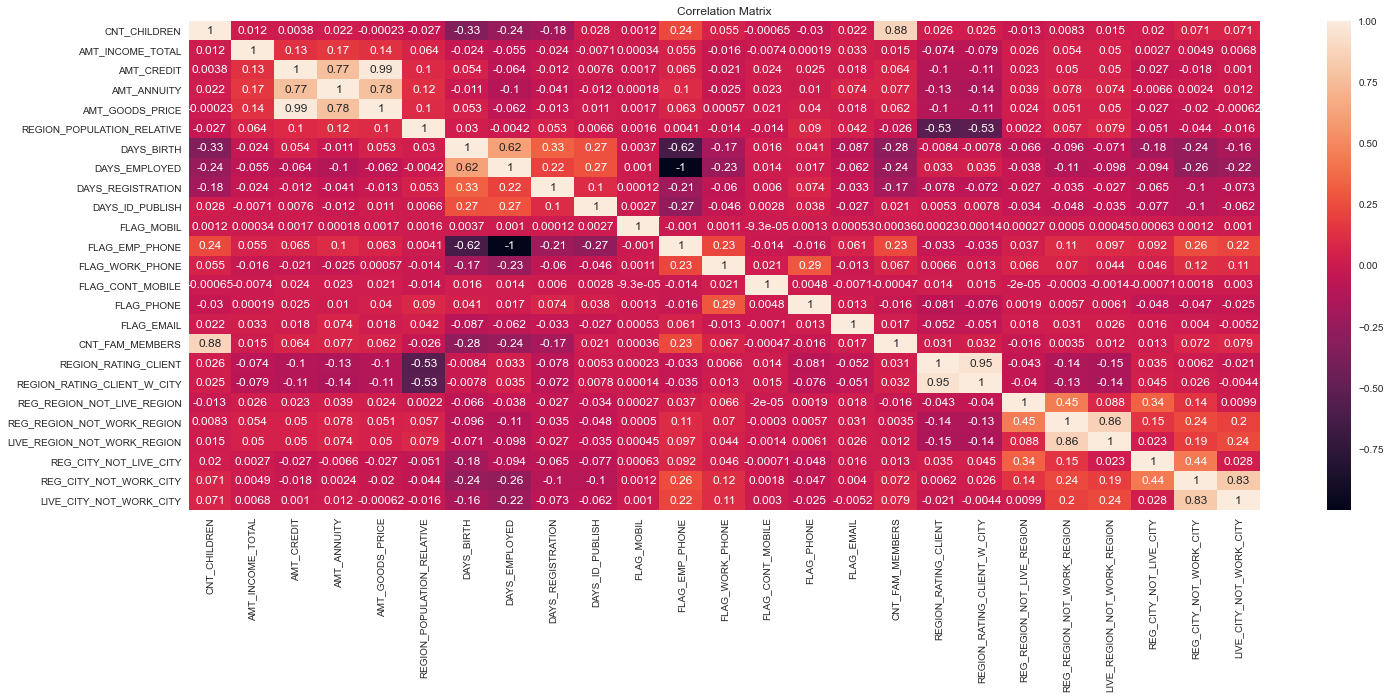

In [23]:
#set up the figure size
plt.figure(figsize=(24, 9))
# heatmap using seaborn
sns.heatmap(X_train.corr(), annot=True, annot_kws={"size": 12})
plt.title('Correlation Matrix')

In [24]:
# Highly correlated features that we want to drop from our dataframe
corr_feature

{'AMT_GOODS_PRICE',
 'CNT_FAM_MEMBERS',
 'FLAG_EMP_PHONE',
 'LIVE_CITY_NOT_WORK_CITY',
 'LIVE_REGION_NOT_WORK_REGION',
 'REGION_RATING_CLIENT_W_CITY'}

In [ ]:
# Removing highly correlated variables from the EDA train/test split.
# (This split is only for the correlation check; the PD model is rebuilt later
# with a stratified split and a sklearn Pipeline.)
X_train = X_train.drop(columns=corr_feature)
X_test = X_test.drop(columns=corr_feature)
print('Dropped collinear features:', sorted(corr_feature))
print('Remaining numeric features:', X_train.shape[1])


### Distribution of application based on Categorization

0    Unaccompanied
dtype: object


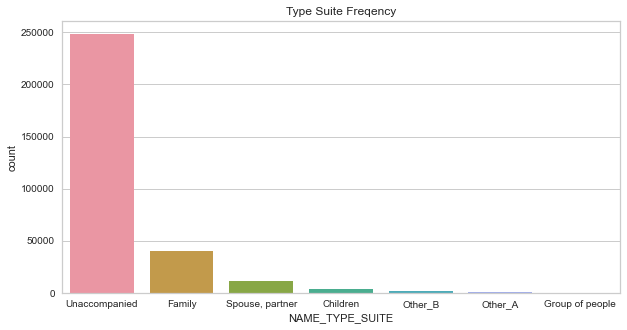

In [26]:
# NAME_TYPE_SUITE column imputation
plt.figure(figsize=(10,5))
sns.countplot(x='NAME_TYPE_SUITE',data=df, order = df['NAME_TYPE_SUITE'].value_counts().index)
plt.title('Type Suite Freqency')
print(df.NAME_TYPE_SUITE.mode())

0    Laborers
dtype: object


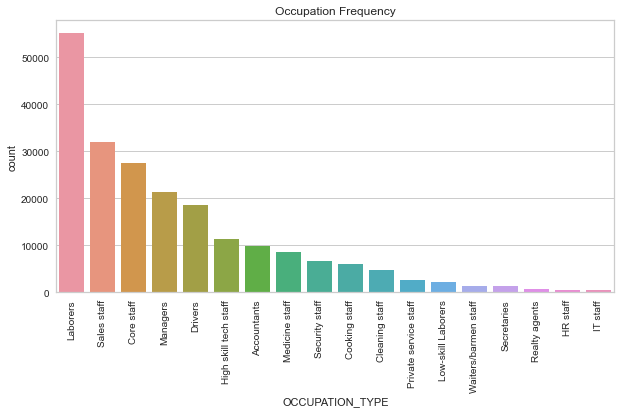

In [27]:
# OCCUPATION_TYPE column imputation
plt.figure(figsize=(10,5))
plt.xticks(rotation=90)
sns.countplot(x='OCCUPATION_TYPE',data=df, order = df['OCCUPATION_TYPE'].value_counts().index)
plt.title('Occupation Frequency')
print(df.OCCUPATION_TYPE.mode())

0    Unaccompanied
dtype: object


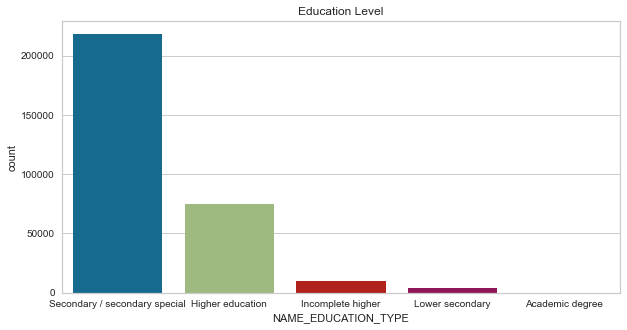

In [28]:
# NAME_EDUCATION_TYPE column imputation
plt.figure(figsize=(10,5))
sns.countplot(x='NAME_EDUCATION_TYPE',data=df, order = df['NAME_EDUCATION_TYPE'].value_counts().index)
plt.title('Education Level')
print(df.NAME_TYPE_SUITE.mode())

0    Unaccompanied
dtype: object


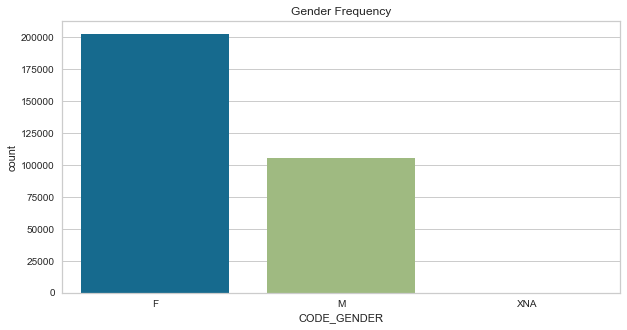

In [29]:
# CODE_GENDER column imputation
plt.figure(figsize=(10,5))
sns.countplot(x='CODE_GENDER',data=df, order = df['CODE_GENDER'].value_counts().index)
plt.title('Gender Frequency')
print(df.NAME_TYPE_SUITE.mode())

### AGE is given in DAYS_BIRTH (in Days), it will be better if we change it to categorical

In [30]:
# Assigning DAYS_BIRTH column to self after dividing by 365 to get year.
df['DAYS_BIRTH']= df['DAYS_BIRTH']/365
# With the help of pandas .cut we will get Categorical AGE column
df['AGE']= pd.cut(df['DAYS_BIRTH'],[0,27,55,70],labels = ['Young','Adult','Elderly'])
# Checking how our Age column looks like
df.AGE

0           Young
1           Adult
2           Adult
3           Adult
4           Adult
           ...   
307506      Young
307507    Elderly
307508      Adult
307509      Adult
307510      Adult
Name: AGE, Length: 307221, dtype: category
Categories (3, object): ['Young' < 'Adult' < 'Elderly']

### Are the distributions of numerical variables the same or different among loan payer or defaulter? Is the loan paid rate different for different values? For example, were people more likely to pay loan if they were younger? 

,AGE,TARGET,percent
0,Young,0,88.537170
1,Young,1,11.462830
2,Adult,0,91.348345
3,Adult,1,8.651655
4,Elderly,0,94.787889
5,Elderly,1,5.212111


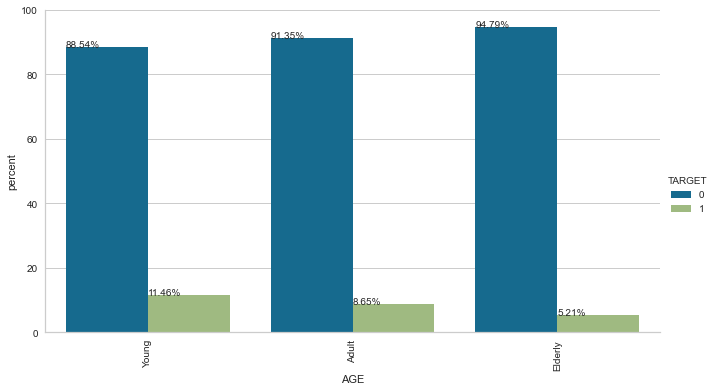

In [31]:
# Assigning variables 
x,y = 'AGE', 'TARGET'
# Group by AGE for TARGET column and normalization is set to True
df1 = df.groupby(x)[y].value_counts(normalize=True)
# It returns multiplication of 100
df1 = df1.mul(100)
# Removing column name to percent
df1 = df1.rename('percent').reset_index()
# plotting bar graph from seaborn, aspect ratio of each facet
g = sns.catplot(x=x,y='percent',hue=y,kind='bar',data=df1,aspect=15/8.27)
# Used to set the y-axis view limits
g.ax.set_ylim(0,100)
# Rotating x ticks vertically
plt.xticks(rotation=90)
# Iterating through g.ax.patches and labeling percentage on top of bar graph
for p in g.ax.patches:
    txt = str(p.get_height().round(2)) + '%'
    txt_x = p.get_x() 
    txt_y = p.get_height()
    g.ax.text(txt_x,txt_y,txt)
df1

### From the chart above we can see that 11.46% of young people fail to pay their loans on time. 

### Are there different payment rates in different categories? For example, did more women paid loan than man?

,CODE_GENDER,TARGET,percent
0,F,0,93.002754
1,F,1,6.997246
2,M,0,89.851952
3,M,1,10.148048
4,XNA,0,100.000000


posx and posy should be finite values
posx and posy should be finite values


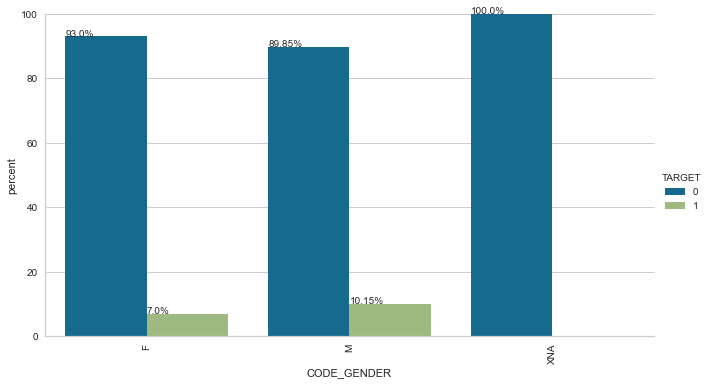

In [32]:
# Assigning variables 
x,y = 'CODE_GENDER', 'TARGET'
# Group by AGE for TARGET column and normalization is set to True
df1 = df.groupby(x)[y].value_counts(normalize=True)
# It returns multiplication of 100
df1 = df1.mul(100)
# Removing column name to percent
df1 = df1.rename('percent').reset_index()
# plotting bar graph from seaborn, aspect ratio of each facet
g = sns.catplot(x=x,y='percent',hue=y,kind='bar',data=df1,aspect=15/8.27)
# Used to set the y-axis view limits
g.ax.set_ylim(0,100)
# Rotating x ticks vertically
plt.xticks(rotation=90)
# Iterating through g.ax.patches and labeling percentage on top of bar graph
for p in g.ax.patches:
    txt = str(p.get_height().round(2)) + '%'
    txt_x = p.get_x() 
    txt_y = p.get_height()
    g.ax.text(txt_x,txt_y,txt)
df1

### Female applicants default at ~7.0% vs ~10.1% for males.

The `XNA` gender code is a tiny missing-data bucket, not a real “100% repayment” segment. Gender is used here for **EDA only**. It is a protected class and is **excluded from the underwriting model** below.


# Look at summary information about data (total, mean, min, max, freq, unique, etc.) Does this present any more questions? Does it lead to a conclusion yet?

In [33]:
# Type of variables in the table
# Describing a DataFrame. By default only numeric fields are returned.
print('Describe Data')
print(df.describe())

Describe Data
              TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT  \
count  307221.000000  307221.000000      3.072210e+05  3.072210e+05   
mean        0.080737       0.416977      1.688326e+05  5.993163e+05   
std         0.272431       0.722047      2.372199e+05  4.025196e+05   
min         0.000000       0.000000      2.565000e+04  4.500000e+04   
25%         0.000000       0.000000      1.125000e+05  2.700000e+05   
50%         0.000000       0.000000      1.485000e+05  5.146020e+05   
75%         0.000000       1.000000      2.025000e+05  8.086500e+05   
max         1.000000      19.000000      1.170000e+08  4.050000e+06   

         AMT_ANNUITY  AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  \
count  307221.000000     3.072210e+05               307221.000000   
mean    27120.225984     5.383973e+05                    0.020870   
std     14492.090836     3.694484e+05                    0.013832   
min      1615.000000     4.050000e+04                    0.000290   
2

In [34]:
# Including only string columns in a DataFrame description.
print('Summarized Data')
print(df.describe(include=['O']))

Summarized Data
       NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
count              307221      307221       307221          307221   
unique                  2           3            2               2   
top            Cash loans           F            N               Y   
freq               278220      202251       202637          213086   

       NAME_TYPE_SUITE NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
count           306207           307221                         307221   
unique               7                8                              5   
top      Unaccompanied          Working  Secondary / secondary special   
freq            248515           158583                         218186   

       NAME_FAMILY_STATUS  NAME_HOUSING_TYPE OCCUPATION_TYPE  \
count              307221             307221          210887   
unique                  5                  6              18   
top               Married  House / apartment        Laborers   
freq  

# Make some bar charts for variables with only a few options.

Text(0, 0.5, 'Counts')

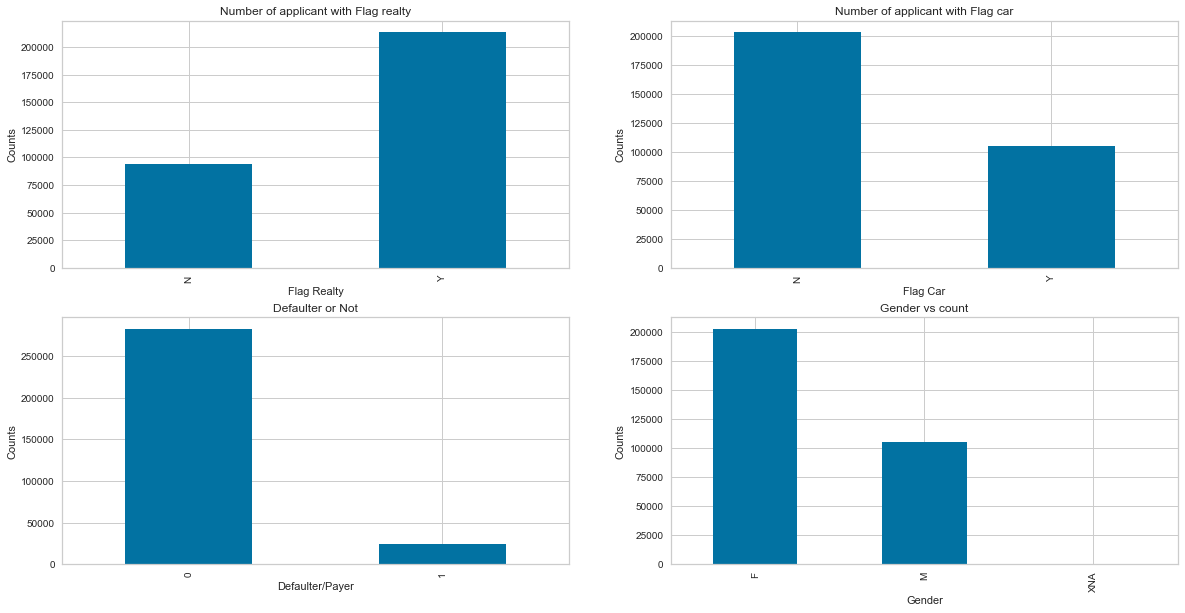

In [35]:
# setting up the figure size
fig, ((axis1, axis2), (axis3, axis4)) = plt.subplots(2 , 2, figsize=(20,10))

# Creating bar chart and labeling x and y axis
df['FLAG_OWN_REALTY'].value_counts().sort_index().plot(kind='bar', ax=axis1)
axis1.title.set_text('Number of applicant with Flag realty')
axis1.set_xlabel('Flag Realty')
axis1.set_ylabel('Counts')

df['FLAG_OWN_CAR'].value_counts().sort_index().plot(kind='bar', ax=axis2)
axis2.title.set_text('Number of applicant with Flag car')
axis2.set_xlabel('Flag Car')
axis2.set_ylabel('Counts')

df['TARGET'].value_counts().sort_index().plot(kind='bar', ax=axis3)
axis3.title.set_text('Defaulter or Not')
axis3.set_xlabel('Defaulter/Payer')
axis3.set_ylabel('Counts')

df['CODE_GENDER'].value_counts().sort_index().plot(kind='bar', ax=axis4)
axis4.title.set_text('Gender vs count')
axis4.set_xlabel('Gender')
axis4.set_ylabel('Counts')

### Distribution of contract type ,gender ,own car ,own house with respect to Repayment status(Target variable)

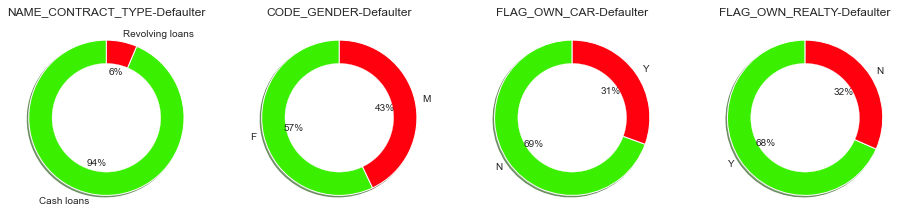

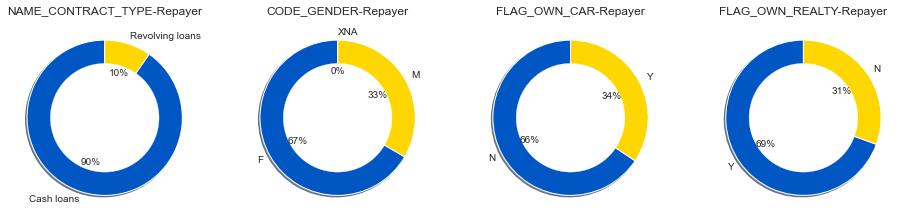

In [36]:
default = df[df["TARGET"]==1][[ 'NAME_CONTRACT_TYPE', 'CODE_GENDER','FLAG_OWN_CAR', 'FLAG_OWN_REALTY']]
non_default = df[df["TARGET"]==0][[ 'NAME_CONTRACT_TYPE', 'CODE_GENDER','FLAG_OWN_CAR', 'FLAG_OWN_REALTY']]

d_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER','FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
d_length = len(d_cols)

fig = plt.figure(figsize=(16,4))
for i,j in itertools.zip_longest(d_cols,range(d_length)):
    plt.subplot(1,4,j+1)
    default[i].value_counts().plot.pie(autopct = "%1.0f%%",colors = sns.color_palette("prism"),startangle = 90,
                                        wedgeprops={"linewidth":1,"edgecolor":"white"},shadow =True)
    circ = plt.Circle((0,0),.7,color="white")
    plt.gca().add_artist(circ)
    plt.ylabel("")
    plt.title(i+"-Defaulter")


fig = plt.figure(figsize=(16,4))
for i,j in itertools.zip_longest(d_cols,range(d_length)):
    plt.subplot(1,4,j+1)
    non_default[i].value_counts().plot.pie(autopct = "%1.0f%%",colors = sns.color_palette("prism",3),startangle = 90,
                                           wedgeprops={"linewidth":1,"edgecolor":"white"},shadow =True)
    circ = plt.Circle((0,0),.7,color="white")
    plt.gca().add_artist(circ)
    plt.ylabel("")
    plt.title(i+"-Repayer")

#### In first column we can see that percentage of cash loans is 4% more in defaults than revovling loans. 
#### In second column we can see that percentage of males is 10% more in defaults than repayers. 

## Top 10 Correlation Fields for Repayer

In [37]:
df_repayer = df[df['TARGET'] == 0]
df_defaulter = df[df['TARGET'] == 1]

In [ ]:
corrmat = df_repayer.corr(numeric_only=True) 
corrdf = corrmat.where(np.triu(np.ones(corrmat.shape), k=1).astype(np.bool))
corrdf = corrdf.unstack().reset_index()
corrdf.columns = ['Var1', 'Var2', 'Correlation']
corrdf.dropna(subset = ['Correlation'], inplace = True)
corrdf['Correlation'] = round(corrdf['Correlation'], 2)
corrdf['Correlation'] = abs(corrdf['Correlation'])
corrdf.sort_values(by = 'Correlation', ascending = False).head(10)


## Top 10 Correlation Fields for Defaulter

In [ ]:
corrmat = df_defaulter.corr(numeric_only=True) 
corrdf = corrmat.where(np.triu(np.ones(corrmat.shape), k=1).astype(np.bool))
corrdf = corrdf.unstack().reset_index()
corrdf.columns = ['Var1', 'Var2', 'Correlation']
corrdf.dropna(subset = ['Correlation'], inplace = True)
corrdf['Correlation'] = round(corrdf['Correlation'], 2)
corrdf['Correlation'] = abs(corrdf['Correlation'])
corrdf.sort_values(by = 'Correlation', ascending = False).head(10)


# To see if the data is correlated, make some Pearson Ranking charts

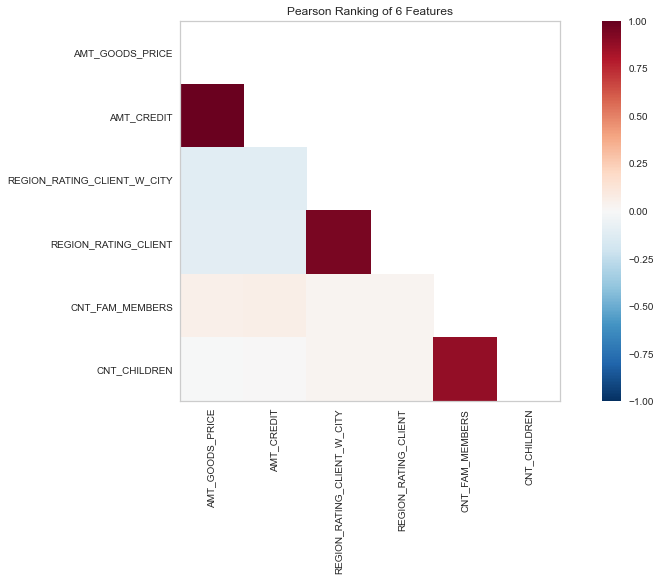

In [40]:
#set up the figure size
plt.rcParams['figure.figsize'] = (15, 7)

# import the package for visulization of the correlation
from yellowbrick.features import Rank2D

# creating list
num_features = ['AMT_GOODS_PRICE', 'AMT_CREDIT', 'REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT',
                'CNT_FAM_MEMBERS', 'CNT_CHILDREN']

# extract the numpy arrays from the data frame
X = df[num_features].values

# instantiate the visualizer with the Covariance ranking algorithm
visualizer = Rank2D(features=num_features, algorithm='pearson')
visualizer.fit(X)                # Fit the data to the visualizer
visualizer.transform(X)             # Transform the data
visualizer.poof(outpath="appdata1.png") # Draw/show/poof the data
plt.show()

### Above Pearson Ranking shows strong relation between ('AMT_GOODS_PRICE', 'AMT_CREDIT'), 
### ('REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT'), ('CNT_FAM_MEMBERS', 'CNT_CHILDREN')

# Use Parallel Coordinates visualization to compare the distributions of numerical variables between applicants who paid loan on time and defaulter.
### Applicants with children at certain region have higher chance of being defaulter with his/her income and the credit amount. 

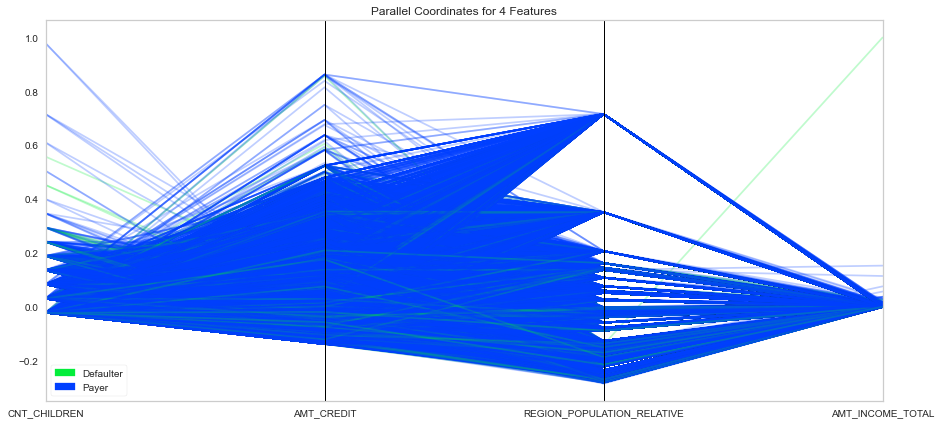

In [41]:
# Compare variables against Payer and Defaulter
#set up the figure size
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['font.size'] = 50

# setup the color for yellowbrick visulizer
from yellowbrick.style import set_palette
set_palette('sns_bright')

# import packages
from yellowbrick.features import ParallelCoordinates
# Specify the features of interest and the classes of the target
classes = ['Payer', 'Defaulter']
num_features = ['CNT_CHILDREN', 'AMT_CREDIT', 'REGION_POPULATION_RELATIVE', 'AMT_INCOME_TOTAL']

# copy data to a new dataframe
data_norm = df.copy()

# normalize data to 0-1 range
for feature in num_features:
    data_norm[feature] = (df[feature] - df[feature].mean(skipna=True)) / (df[feature].max(skipna=True) - df[feature].min(skipna=True))

# Extract the numpy arrays from the data frame
X = data_norm[num_features].values
y = df.TARGET.values


# Instantiate the visualizer, it takes classes and features that we created above
visualizer = ParallelCoordinates(classes=classes, features=num_features)


visualizer.fit(X, y)      # Fit the data to the visualizer
visualizer.transform(X)   # Transform the data
visualizer.poof(outpath="pcoords2.png") # Draw/show/poof the data
plt.show()


# Use Stack Bar Charts to compare applicants who paid loan on time and who didn’t based on the other variables.
### a. More females paid on time than men.  Lower education level had hard time to pay back their loans. Cash loan type is paid more than revolving loan type. 

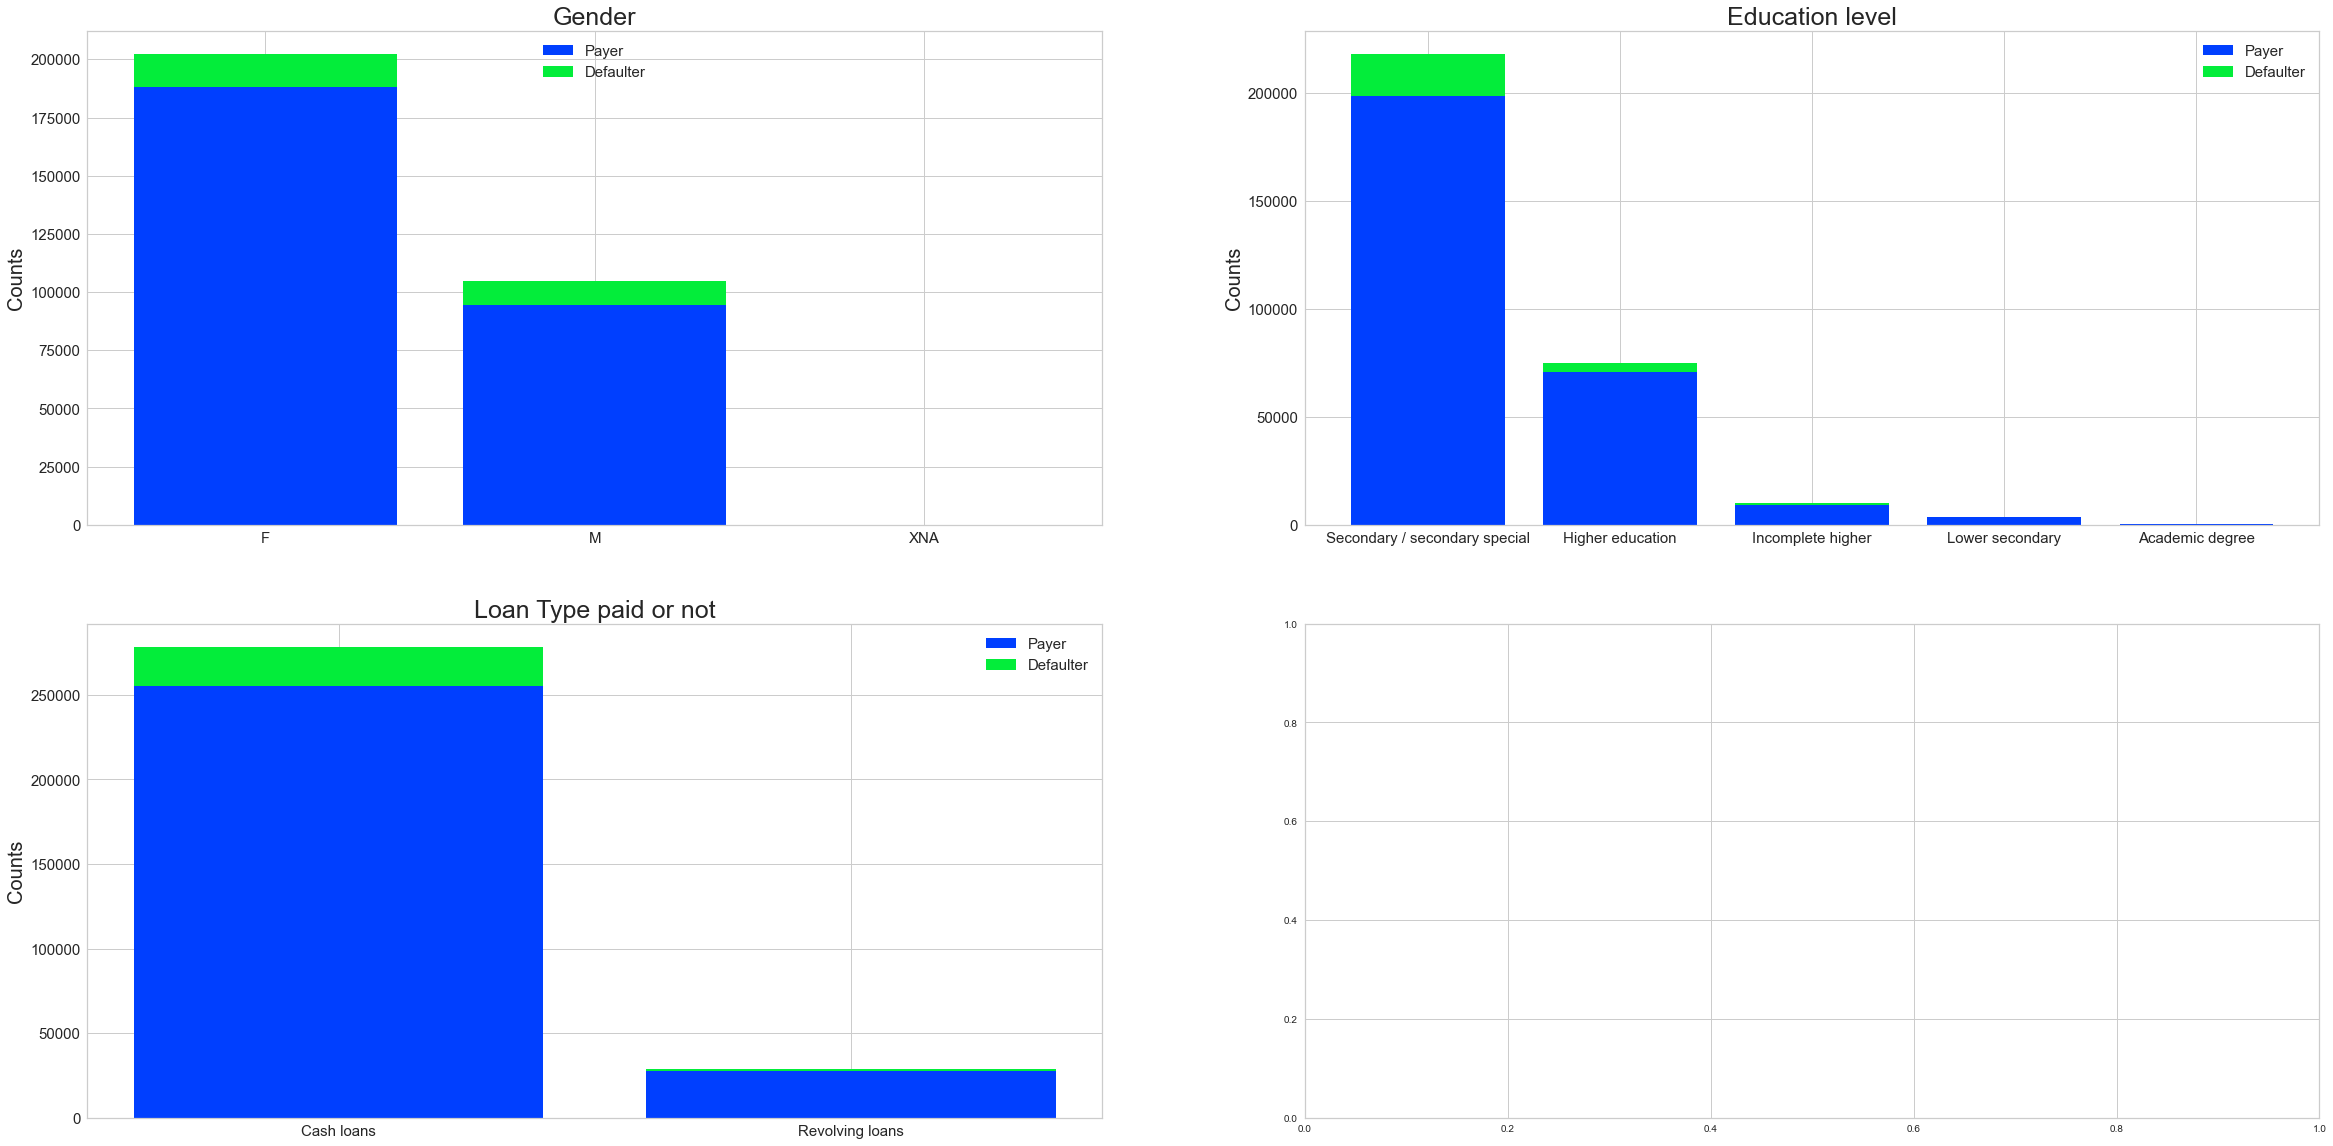

In [42]:
# Setting figure size
fig, ((axis1, axis2), (axis3, axis4)) = plt.subplots(2 , 2, figsize=(40,20))

# make the data read to feed into the visulizer
# It creates a variable which replaces 0 and 1 with Payer and Defaulter respectively, 
# which counts value of PAYER in regards to male and female
# Same goes with Defaulter in terms of CODE_GENDER variable. 
# Implementing same index for two variables
Gender_payer = df.replace({'TARGET': {1: 'Defaulter', 0: 'Payer'}})[df['TARGET']==0]['CODE_GENDER'].value_counts()
Gender_defaulter = df.replace({'TARGET': {1: 'Defaulter', 0: 'Payer'}})[df['TARGET']==1]['CODE_GENDER'].value_counts()
Gender_defaulter = Gender_defaulter.reindex(index = Gender_payer.index)

# make the bar plot
# It will stack survived values to the bottom and not survived values to the top.
p1 = axis1.bar(Gender_payer.index, Gender_payer.values)
p2 = axis1.bar(Gender_defaulter.index, Gender_defaulter.values, bottom=Gender_payer.values)
axis1.set_title('Gender', fontsize=25)
axis1.set_ylabel('Counts', fontsize=20)
axis1.tick_params(axis='both', labelsize=15)
axis1.legend((p1[0], p2[0]), ('Payer', 'Defaulter'), fontsize = 15)


# make the data read to feed into the visualizer
Edu_payer = df.replace({'TARGET': {1: 'Defaulter', 0: 'Payer'}})[df['TARGET']==0]['NAME_EDUCATION_TYPE'].value_counts()
Edu_Defaulter = df.replace({'TARGET': {1: 'Defaulter', 0: 'Payer'}})[df['TARGET']==1]['NAME_EDUCATION_TYPE'].value_counts()
Edu_Defaulter = Edu_Defaulter.reindex(index = Edu_payer.index)

# make the bar plot
p3 = axis2.bar(Edu_payer.index, Edu_payer.values)
p4 = axis2.bar(Edu_Defaulter.index, Edu_Defaulter.values, bottom=Edu_payer.values)
axis2.set_title('Education level', fontsize=25)
axis2.set_ylabel('Counts', fontsize=20)
axis2.tick_params(axis='both', labelsize=15)
axis2.legend((p3[0], p4[0]), ('Payer', 'Defaulter'), fontsize = 15)

# make the data read to feed into the visualizer
loan_type_payer = df.replace({'TARGET': {1: 'Defaulter', 0: 'Payer'}})[df['TARGET']==0]['NAME_CONTRACT_TYPE'].value_counts()
loan_type_defaulter = df.replace({'TARGET': {1: 'Defaulter', 0: 'Payer'}})[df['TARGET']==1]['NAME_CONTRACT_TYPE'].value_counts()
loan_type_defaulter = loan_type_defaulter.reindex(index = loan_type_payer.index)

# make the bar plot
p5 = axis3.bar(loan_type_payer.index, loan_type_payer.values)
p6 = axis3.bar(loan_type_defaulter.index, loan_type_defaulter.values, bottom=loan_type_payer.values)
axis3.set_title('Loan Type paid or not', fontsize=25)
axis3.set_ylabel('Counts', fontsize=20)
axis3.tick_params(axis='both', labelsize=15)
axis3.legend((p5[0], p6[0]), ('Payer', 'Defaulter'), fontsize = 15)
plt.show()

### From the graph above we can conclude that Female paid on time loan more than male; It is less likely to pay if you have low education; and finally Cash loans are paid more than revovling loans.

# Part 3 — Probability of default model

EDA above established the story: default is rare (~8%), younger and lower-education applicants are riskier, and raw income/credit overlap between classes. The original 6-feature logistic model (region rating, children, gender, car, realty) only reached **~45% default recall** after oversampling — there was almost no credit signal left.

This section refits a **leakage-safe** PD pipeline:

1. Row-wise features only (ratios, employment years, sentinel flag)
2. **Stratified** 75/25 split
3. Imputation and encoding **fit on train only** (`Pipeline` + `ColumnTransformer`)
4. Logistic regression as an interpretable scorecard vs histogram gradient boosting as a challenger
5. Credit-risk metrics: **ROC-AUC, PR-AUC, KS, Gini**, then a **cost-weighted threshold**

Gender is held out of the model (fair lending). Collinear twins (`AMT_GOODS_PRICE`, `REGION_RATING_CLIENT_W_CITY`, `CNT_FAM_MEMBERS`) stay out; their information is kept via ratios and `CNT_CHILDREN`.


### Default rate by income decile

Income alone does not separate classes (the parallel-coordinates plot showed overlap), but the **rate** still moves across the income distribution. That is a business chart, not a modeling leak: the decile is descriptive.


In [ ]:
income_decile = pd.qcut(df['AMT_INCOME_TOTAL'], 10, duplicates='drop')
default_by_income = (
    df.groupby(income_decile, observed=True)['TARGET']
      .mean()
      .mul(100)
      .rename('default_rate_pct')
)

ax = default_by_income.plot(kind='bar', figsize=(12, 5), color='steelblue')
ax.set_title('Default rate by income decile')
ax.set_xlabel('Income decile (low → high)')
ax.set_ylabel('Default rate (%)')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
default_by_income


### Feature set for the PD model

All transforms below are **row-wise** (no statistics from other applicants), so they can be computed before the split. Median/mode imputation and one-hot encoding happen **inside** the pipeline after the split.


In [ ]:
model_df = df.copy()

# DAYS_BIRTH was converted to years during EDA. DAYS_EMPLOYED is still in days,
# with NaN where FLAG_UNEMPLOYED marks the 365243 sentinel.
model_df['AGE_YEARS'] = model_df['DAYS_BIRTH']
model_df['YEARS_EMPLOYED'] = model_df['DAYS_EMPLOYED'] / 365.0
model_df.loc[model_df['FLAG_UNEMPLOYED'] == 1, 'YEARS_EMPLOYED'] = 0.0

# Payment burden and LTV-style ratios — the credit-risk features interviewers expect
model_df['ANNUITY_INCOME_RATIO'] = (
    model_df['AMT_ANNUITY'] / model_df['AMT_INCOME_TOTAL'].replace(0, np.nan)
)
model_df['CREDIT_INCOME_RATIO'] = (
    model_df['AMT_CREDIT'] / model_df['AMT_INCOME_TOTAL'].replace(0, np.nan)
)
model_df['CREDIT_GOODS_RATIO'] = (
    model_df['AMT_CREDIT'] / model_df['AMT_GOODS_PRICE'].replace(0, np.nan)
)

numeric_features = [
    'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AGE_YEARS', 'YEARS_EMPLOYED',
    'CNT_CHILDREN', 'REGION_RATING_CLIENT', 'REGION_POPULATION_RELATIVE',
    'FLAG_UNEMPLOYED',
    'ANNUITY_INCOME_RATIO', 'CREDIT_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
]
categorical_features = [
    'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
]

X = model_df[numeric_features + categorical_features]
y = model_df['TARGET']

print('Feature matrix:', X.shape)
print('Default rate: {:.2f}%'.format(100 * y.mean()))
X.isna().mean().sort_values(ascending=False).head(10)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print('Train:', X_train.shape[0], 'Test:', X_test.shape[0])
print('Train default rate: {:.2f}%'.format(100 * y_train.mean()))
print('Test  default rate: {:.2f}%'.format(100 * y_test.mean()))
print(y_train.value_counts())
print(y_test.value_counts())


### Preprocessor (fit on train only)

`OneHotEncoder(handle_unknown='ignore')` so unseen occupation / income-type levels in test do not crash scoring.


In [ ]:
def make_onehot():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def make_preprocessor():
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_onehot()),
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features),
    ])

def make_logistic(class_weight=None):
    return Pipeline([
        ('prep', make_preprocessor()),
        ('clf', LogisticRegression(
            solver='liblinear',
            class_weight=class_weight,
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ])

def make_hgb():
    # Histogram boosting: fast on ~230k rows; class_weight supported in recent sklearn
    try:
        clf = HistGradientBoostingClassifier(
            max_depth=6,
            learning_rate=0.08,
            max_iter=200,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )
    except TypeError:
        clf = HistGradientBoostingClassifier(
            max_depth=6,
            learning_rate=0.08,
            max_iter=200,
            random_state=RANDOM_STATE,
        )
    return Pipeline([
        ('prep', make_preprocessor()),
        ('clf', clf),
    ])


### Credit-risk metrics

Accuracy is reported only so it can be compared with the ~92% majority baseline. **PR-AUC** matters more than ROC-AUC here because defaults are 8% of the file. **KS** and **Gini** are the language of a credit-risk team.


In [ ]:
def ks_statistic(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(np.abs(tpr - fpr)))

def gini_coefficient(auc):
    return 2 * auc - 1

def evaluate_model(name, model, X_te, y_te, threshold=0.5):
    y_score = model.predict_proba(X_te)[:, 1]
    y_pred = (y_score >= threshold).astype(int)
    auc = roc_auc_score(y_te, y_score)
    pr_auc = average_precision_score(y_te, y_score)
    return {
        'model': name,
        'threshold': threshold,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision_default': precision_score(y_te, y_pred, pos_label=1, zero_division=0),
        'recall_default': recall_score(y_te, y_pred, pos_label=1, zero_division=0),
        'f1_default': f1_score(y_te, y_pred, pos_label=1, zero_division=0),
        'roc_auc': auc,
        'pr_auc': pr_auc,
        'ks': ks_statistic(y_te, y_score),
        'gini': gini_coefficient(auc),
    }, y_score, y_pred

def show_confusion(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Payer (0)', 'Defaulter (1)'],
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'TN (correct payers)={tn:,}  FP (false rejects)={fp:,}')
    print(f'FN (missed defaults)={fn:,}  TP (caught defaults)={tp:,}')
    print(f'Default recall = TP / (TP+FN) = {tp / (tp + fn):.1%}')


In [ ]:
# Majority-class baseline: always predict payer
dummy = DummyClassifier(strategy='most_frequent')
log_unbalanced = make_logistic(class_weight=None)
log_balanced = make_logistic(class_weight='balanced')
hgb = make_hgb()

dummy.fit(X_train, y_train)
log_unbalanced.fit(X_train, y_train)
log_balanced.fit(X_train, y_train)
hgb.fit(X_train, y_train)

# Train-only random oversampling (same idea as the original notebook, now with real features)
train_os = pd.concat([X_train, y_train], axis=1)
payers = train_os[train_os['TARGET'] == 0]
defaulters = train_os[train_os['TARGET'] == 1]
defaulters_os = resample(
    defaulters, replace=True, n_samples=len(payers), random_state=RANDOM_STATE
)
os = pd.concat([payers, defaulters_os])
X_train_os = os.drop(columns='TARGET')
y_train_os = os['TARGET']
log_oversampled = make_logistic(class_weight=None)
log_oversampled.fit(X_train_os, y_train_os)
print('Oversampled train class counts:\n', y_train_os.value_counts())


In [ ]:
models = {
    'Dummy (always pay)': dummy,
    'Logistic (no balancing)': log_unbalanced,
    'Logistic (class_weight=balanced)': log_balanced,
    'Logistic (random oversample)': log_oversampled,
    'HistGradientBoosting (balanced)': hgb,
}

rows = []
scores = {}
for name, model in models.items():
    metrics, y_score, y_pred = evaluate_model(name, model, X_test, y_test, threshold=0.5)
    rows.append(metrics)
    scores[name] = (y_score, y_pred)

results = pd.DataFrame(rows).set_index('model')
display_cols = [
    'accuracy', 'precision_default', 'recall_default', 'f1_default',
    'roc_auc', 'pr_auc', 'ks', 'gini',
]
results[display_cols].round(3)


At threshold 0.5, **class-weighted logistic** and **boosting** should catch far more defaulters than the dummy or unbalanced logistic. Accuracy will drop below 92% — that is the model stopping ignoring the 8% default class, not a failure.


In [ ]:
# Confusion matrices for the two models a credit committee would actually discuss
for name in [
    'Logistic (class_weight=balanced)',
    'HistGradientBoosting (balanced)',
]:
    _, y_pred = scores[name]
    show_confusion(y_test, y_pred, f'{name} @ threshold 0.5')
    print(classification_report(
        y_test, y_pred, target_names=['Payer', 'Defaulter'], digits=3
    ))
    print()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, (y_score, _) in scores.items():
    RocCurveDisplay.from_predictions(y_test, y_score, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_score, name=name, ax=axes[1])

axes[0].set_title('ROC (ranking quality)')
axes[1].set_title('Precision–recall (default class)')
axes[1].axhline(y_test.mean(), color='black', ls=':', lw=1, label='base default rate')
axes[1].legend(loc='upper right', fontsize=8)
axes[0].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


### Cost-weighted threshold

A 0.5 cutoff is arbitrary. Suppose a missed default (**FN**) costs **5×** a false reject (**FP**) — a stylized loss-given-default vs. lost-margin ratio, not a bank’s real LGD. Sweep the threshold on the **test scores** of the boosting model and pick the cutoff that minimizes `5·FN + 1·FP`.

In production you would tune this on a **validation** fold, not the final test set. The plot is here to show the business lever, not to claim a fully nested selection.


In [ ]:
COST_FP = 1   # false reject: lost origination / margin
COST_FN = 5   # missed default: credit loss (stylized)

best_name = 'HistGradientBoosting (balanced)'
y_score = scores[best_name][0]
thresholds = np.linspace(0.05, 0.80, 76)

cost_rows = []
for t in thresholds:
    y_hat = (y_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat, labels=[0, 1]).ravel()
    cost_rows.append({
        'threshold': t,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'recall_default': tp / (tp + fn),
        'approval_rate': (tn + fn) / len(y_test),  # predicted payer
        'expected_cost': COST_FP * fp + COST_FN * fn,
    })

cost_df = pd.DataFrame(cost_rows)
best = cost_df.loc[cost_df['expected_cost'].idxmin()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cost_df['threshold'], cost_df['expected_cost'], color='steelblue')
ax.axvline(best['threshold'], color='black', ls='--', label=f"min cost @ {best['threshold']:.2f}")
ax.set_xlabel('PD threshold (predict default if score ≥ t)')
ax.set_ylabel(f'Cost = {COST_FN}·FN + {COST_FP}·FP')
ax.set_title(f'Expected cost vs threshold — {best_name}')
ax.legend()
plt.show()

print('Cost-minimizing threshold: {:.2f}'.format(best['threshold']))
print('Default recall: {:.1%}'.format(best['recall_default']))
print('Implied approval rate (predicted payer): {:.1%}'.format(best['approval_rate']))
print('FP={:,.0f}  FN={:,.0f}  TP={:,.0f}'.format(best['fp'], best['fn'], best['tp']))

y_pred_cost = (y_score >= best['threshold']).astype(int)
show_confusion(y_test, y_pred_cost, f'{best_name} @ cost-min threshold {best["threshold"]:.2f}')


### Logistic coefficients (scorecard view)

After scaling, the sign of a coefficient is the direction of risk. External scores should come in **negative** (higher EXT_SOURCE → lower PD). Annuity-to-income and the unemployed flag should come in **positive**.


In [ ]:
prep = log_balanced.named_steps['prep']
clf = log_balanced.named_steps['clf']
try:
    feat_names = prep.get_feature_names_out()
except Exception:
    ohe = prep.named_transformers_['cat'].named_steps['onehot']
    try:
        cat_names = ohe.get_feature_names_out(categorical_features)
    except Exception:
        cat_names = ohe.get_feature_names(categorical_features)
    feat_names = np.concatenate([
        [f'num__{c}' for c in numeric_features],
        [f'cat__{c}' for c in cat_names],
    ])

coef = pd.Series(clf.coef_[0], index=feat_names).sort_values()
top = pd.concat([coef.head(12), coef.tail(12)])
colors = np.where(top < 0, 'steelblue', 'indianred')
ax = top.plot(kind='barh', figsize=(10, 8), color=colors)
ax.set_title('Logistic regression — strongest coefficients (class_weight=balanced)')
ax.set_xlabel('Coefficient (standardized features)')
plt.tight_layout()
plt.show()
coef.abs().sort_values(ascending=False).head(15)


## What this notebook now shows

- **Accuracy is the wrong headline.** The dummy model is ~92% accurate. Any serious PD model will look “worse” on accuracy and better on default recall, PR-AUC, KS, and Gini.
- **The original 6-feature oversampled logistic (66% accuracy, ~45% default recall) was limited by features, not by the classifier.** Restoring income, burden ratios, employment (with the 365243 sentinel), education, occupation, and `EXT_SOURCE_2/3` is the actual upgrade.
- **Class weights vs random oversampling.** Both rebalance training; class weights keep the original 230k rows and do not duplicate defaulters. Compare them on PR-AUC, not accuracy.
- **Threshold is a business choice.** 0.5 is not sacred. The cost curve is how a risk team turns a PD into approve / refer / decline.
- **Gender stayed in EDA and out of the model.** A production monitor would still check residual default-rate gaps by gender after exclusion (adverse impact).

Not done here (honest scope): bureau/previous-application tables, a WoE/IV scorecard, nested threshold selection, and a deployment API.
